In [1]:
import pandas as pd

df = pd.read_csv("data/raw/DataCoSupplyChainDataset.csv", encoding="latin-1")

print(df.shape)

df.head()

(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [2]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [6]:
df.columns = [c.strip() for c in df.columns]

In [7]:
carrier_map = {
    "Standard Class": "Carrier A (Ground)",
    "Second Class": "Carrier B (Expedited)",
    "First Class": "Carrier B (Expedited)",
    "Same Day": "Carrier C (Premium)",
}
df["carrier"] = df["Shipping Mode"].map(carrier_map).fillna("Carrier A (Ground)")

df["carrier"].value_counts()

carrier
Carrier A (Ground)       107752
Carrier B (Expedited)     63030
Carrier C (Premium)        9737
Name: count, dtype: int64

In [8]:
df["warehouse"] = df["Order Region"].astype(str).str.strip()

df["warehouse"].value_counts()

warehouse
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Eastern Asia        7280
East of USA         6915
West Asia           6009
US Center           5887
South of  USA       4045
Eastern Europe      3920
West Africa         3696
North Africa        3232
East Africa         1852
Central Africa      1677
Southern Africa     1157
Canada               959
Central Asia         553
Name: count, dtype: int64

In [9]:
df["warehouse"].nunique()

23

In [10]:
df["warehouse"].value_counts()

warehouse
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Eastern Asia        7280
East of USA         6915
West Asia           6009
US Center           5887
South of  USA       4045
Eastern Europe      3920
West Africa         3696
North Africa        3232
East Africa         1852
Central Africa      1677
Southern Africa     1157
Canada               959
Central Asia         553
Name: count, dtype: int64

SyntaxError: unmatched ')' (300496786.py, line 1)

In [12]:
warehouse_map = {
    # North America — 5 regions → 1
    "West of USA": "North America",
    "East of USA": "North America",
    "South of  USA": "North America",   # note: dataset has a double space here
    "US Center": "North America",
    "Canada": "North America",

    # Central America
    "Central America": "Central America",

    # South America
    "South America": "South America",

    # Caribbean
    "Caribbean": "Caribbean",

    # Europe — kept as 4 separate buckets (each has solid volume)
    "Western Europe": "Western Europe",
    "Northern Europe": "Northern Europe",
    "Southern Europe": "Southern Europe",
    "Eastern Europe": "Eastern Europe",

    # Asia — 5 regions → 2
    "Southeast Asia": "East & Southeast Asia",
    "Eastern Asia": "East & Southeast Asia",
    "South Asia": "South & Central Asia",
    "West Asia": "South & Central Asia",
    "Central Asia": "South & Central Asia",

    # Oceania
    "Oceania": "Oceania",

    # Africa — 5 regions → 1
    "West Africa": "Africa",
    "North Africa": "Africa",
    "East Africa": "Africa",
    "Central Africa": "Africa",
    "Southern Africa": "Africa",
}

df["warehouse"] = df["Order Region"].astype(str).str.strip().map(warehouse_map)

df["warehouse"].nunique(), df["warehouse"].value_counts()

(12,
 warehouse
 Central America          28341
 Western Europe           27109
 North America            25799
 East & Southeast Asia    16819
 South America            14935
 South & Central Asia     14293
 Africa                   11614
 Oceania                  10148
 Northern Europe           9792
 Southern Europe           9431
 Caribbean                 8318
 Eastern Europe            3920
 Name: count, dtype: int64)

In [13]:
df["days_scheduled"] = df["Days for shipment (scheduled)"]
df["days_actual"] = df["Days for shipping (real)"]
df["delay_days"] = df["days_actual"] - df["days_scheduled"]
df["sla_breach"] = (df["Late_delivery_risk"] == 1).astype(int)

df[["days_scheduled", "days_actual", "delay_days", "sla_breach"]].describe()

,days_scheduled,days_actual,delay_days,sla_breach
count,180519.000000,180519.000000,180519.000000,180519.000000
mean,2.931847,3.497654,0.565807,0.548291
std,1.374449,1.623722,1.490966,0.497664
min,0.000000,0.000000,-2.000000,0.000000
25%,2.000000,2.000000,0.000000,0.000000
50%,4.000000,3.000000,1.000000,1.000000
75%,4.000000,5.000000,1.000000,1.000000
max,4.000000,6.000000,4.000000,1.000000


In [14]:
df["order_date"] = pd.to_datetime(df["order date (DateOrders)"], errors="coerce")
df["order_week"] = df["order_date"].dt.to_period("W").dt.start_time
df["order_month"] = df["order_date"].dt.to_period("M").dt.start_time

df["order_date"].isna().sum(), df["order_date"].min(), df["order_date"].max()

(np.int64(0),
 Timestamp('2015-01-01 00:00:00'),
 Timestamp('2018-01-31 23:38:00'))

In [15]:
df["route"] = df["warehouse"] + " | " + df["carrier"]

df["route"].nunique()

36

In [16]:
keep_cols = [
    "Order Id", "order_date", "order_week", "order_month",
    "warehouse", "carrier", "route",
    "days_scheduled", "days_actual", "delay_days", "sla_breach",
    "Order Item Discount Rate", "Order Item Product Price",
    "Order Item Quantity", "Order Item Profit Ratio",
    "Benefit per order", "Sales per customer",
    "Customer Segment", "Market", "Order Status",
]
clean = df[[c for c in keep_cols if c in df.columns]].copy()
clean = clean.dropna(subset=["order_date"])

clean.shape

(180519, 20)

In [17]:
if len(clean) > 50000:
    clean = clean.sample(n=50000, random_state=42).sort_values("order_date")

clean.to_csv("data/processed/shipments.csv", index=False)
print(f"Saved {len(clean):,} rows")

Saved 50,000 rows


In [18]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///data/processed/supply_chain.db")
clean.to_sql("shipments", engine, if_exists="replace", index=False)
print("Loaded into supply_chain.db as table 'shipments'")

Loaded into supply_chain.db as table 'shipments'


In [19]:
clean.columns.tolist()

['Order Id',
 'order_date',
 'order_week',
 'order_month',
 'warehouse',
 'carrier',
 'route',
 'days_scheduled',
 'days_actual',
 'delay_days',
 'sla_breach',
 'Order Item Discount Rate',
 'Order Item Product Price',
 'Order Item Quantity',
 'Order Item Profit Ratio',
 'Benefit per order',
 'Sales per customer',
 'Customer Segment',
 'Market',
 'Order Status']

In [20]:
if len(clean) > 50000:
    clean = clean.sample(n=50000, random_state=42).sort_values("order_date")

clean.to_csv("data/processed/shipments.csv", index=False)
print(f"Saved {len(clean):,} rows")

Saved 50,000 rows


In [21]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///data/processed/supply_chain.db")
clean.to_sql("shipments", engine, if_exists="replace", index=False)
print("Loaded into supply_chain.db as table 'shipments'")

Loaded into supply_chain.db as table 'shipments'


In [22]:
import pandas as pd

query1 = """
SELECT
    COUNT(*) AS total_shipments,
    SUM(sla_breach) AS breaches,
    ROUND(100.0 * SUM(sla_breach) / COUNT(*), 2) AS breach_pct
FROM shipments;
"""
pd.read_sql_query(query1, engine)

,total_shipments,breaches,breach_pct
0,50000,27442,54.88


In [23]:
query3 = """
SELECT
    carrier,
    COUNT(*) AS shipments,
    ROUND(AVG(delay_days), 2) AS avg_delay_days,
    ROUND(100.0 * SUM(sla_breach) / COUNT(*), 2) AS breach_pct
FROM shipments
GROUP BY carrier
ORDER BY breach_pct DESC;
"""
pd.read_sql_query(query3, engine)

,carrier,shipments,avg_delay_days,breach_pct
0,Carrier B (Expedited),17364,1.55,84.74
1,Carrier C (Premium),2735,0.48,46.51
2,Carrier A (Ground),29901,0.00,38.31


In [24]:
query4 = """
SELECT
    route,
    warehouse,
    carrier,
    COUNT(*) AS shipments,
    ROUND(AVG(delay_days), 2) AS avg_delay_days,
    ROUND(100.0 * SUM(sla_breach) / COUNT(*), 2) AS breach_pct
FROM shipments
GROUP BY route
HAVING COUNT(*) >= 30
ORDER BY breach_pct DESC
LIMIT 15;
"""
top_routes = pd.read_sql_query(query4, engine)
top_routes

,route,warehouse,carrier,shipments,avg_delay_days,breach_pct
0,Southern Europe | Carrier B (Expedited),Southern Europe,Carrier B (Expedited),863,1.56,87.49
1,Africa | Carrier B (Expedited),Africa,Carrier B (Expedited),1049,1.54,86.75
2,East & Southeast Asia | Carrier B (Expedited),East & Southeast Asia,Carrier B (Expedited),1549,1.56,85.60
3,Eastern Europe | Carrier B (Expedited),Eastern Europe,Carrier B (Expedited),399,1.57,85.21
4,South & Central Asia | Carrier B (Expedited),South & Central Asia,Carrier B (Expedited),1427,1.58,85.00
5,Northern Europe | Carrier B (Expedited),Northern Europe,Carrier B (Expedited),935,1.56,84.81
6,Western Europe | Carrier B (Expedited),Western Europe,Carrier B (Expedited),2709,1.58,84.75
7,Caribbean | Carrier B (Expedited),Caribbean,Carrier B (Expedited),778,1.60,84.70
8,South America | Carrier B (Expedited),South America,Carrier B (Expedited),1404,1.54,84.19
9,Central America | Carrier B (Expedited),Central America,Carrier B (Expedited),2730,1.48,84.18


In [26]:
query5 = """
SELECT
    MIN(breach_pct) AS min_breach_pct,
    MAX(breach_pct) AS max_breach_pct,
    MAX(breach_pct) - MIN(breach_pct) AS spread
FROM (
    SELECT
        warehouse,
        ROUND(100.0 * SUM(sla_breach) / COUNT(*), 2) AS breach_pct
    FROM shipments
    WHERE carrier = 'Carrier B (Expedited)'
    GROUP BY warehouse
    HAVING COUNT(*) >= 30
);
"""
pd.read_sql_query(query5, engine)

,min_breach_pct,max_breach_pct,spread
0,82.87,87.49,4.62


In [27]:
query6 = """
SELECT
    carrier,
    SUM(sla_breach) AS breaches,
    ROUND(100.0 * SUM(sla_breach) / (SELECT SUM(sla_breach) FROM shipments), 2) AS pct_of_all_breaches
FROM shipments
GROUP BY carrier
ORDER BY breaches DESC;
"""
pd.read_sql_query(query6, engine)

,carrier,breaches,pct_of_all_breaches
0,Carrier B (Expedited),14715,53.62
1,Carrier A (Ground),11455,41.74
2,Carrier C (Premium),1272,4.64


In [30]:
query7 = """
SELECT route, shipments, breach_pct
FROM (
    SELECT
        route,
        COUNT(*) AS shipments,
        ROUND(100.0 * SUM(sla_breach)/COUNT(*), 2) AS breach_pct
    FROM shipments
    WHERE carrier = 'Carrier B (Expedited)'
    GROUP BY route
    HAVING COUNT(*) >= 30
)
ORDER BY breach_pct DESC;
"""
pd.read_sql_query(query7, engine)

,route,shipments,breach_pct
0,Southern Europe | Carrier B (Expedited),863,87.49
1,Africa | Carrier B (Expedited),1049,86.75
2,East & Southeast Asia | Carrier B (Expedited),1549,85.60
3,Eastern Europe | Carrier B (Expedited),399,85.21
4,South & Central Asia | Carrier B (Expedited),1427,85.00
5,Northern Europe | Carrier B (Expedited),935,84.81
6,Western Europe | Carrier B (Expedited),2709,84.75
7,Caribbean | Carrier B (Expedited),778,84.70
8,South America | Carrier B (Expedited),1404,84.19
9,Central America | Carrier B (Expedited),2730,84.18


In [31]:
carrier_summary = pd.read_sql_query("""
SELECT
    carrier,
    COUNT(*) AS shipments,
    ROUND(100.0 * SUM(sla_breach)/COUNT(*), 2) AS breach_pct,
    SUM(sla_breach) AS breaches,
    ROUND(100.0 * SUM(sla_breach) / (SELECT SUM(sla_breach) FROM shipments), 2) AS pct_of_all_breaches
FROM shipments
GROUP BY carrier
ORDER BY breach_pct DESC;
""", engine)

carrier_summary.to_csv("data/processed/carrier_summary.csv", index=False)
carrier_summary

,carrier,shipments,breach_pct,breaches,pct_of_all_breaches
0,Carrier B (Expedited),17364,84.74,14715,53.62
1,Carrier C (Premium),2735,46.51,1272,4.64
2,Carrier A (Ground),29901,38.31,11455,41.74


In [32]:
warehouse_carrierB = pd.read_sql_query("""
SELECT warehouse, shipments, breach_pct
FROM (
    SELECT warehouse, COUNT(*) AS shipments,
           ROUND(100.0*SUM(sla_breach)/COUNT(*),2) AS breach_pct
    FROM shipments WHERE carrier='Carrier B (Expedited)'
    GROUP BY warehouse HAVING COUNT(*)>=30
) ORDER BY breach_pct DESC;
""", engine)

warehouse_carrierB.to_csv("data/processed/warehouse_carrierB_breakdown.csv", index=False)
warehouse_carrierB

,warehouse,shipments,breach_pct
0,Southern Europe,863,87.49
1,Africa,1049,86.75
2,East & Southeast Asia,1549,85.60
3,Eastern Europe,399,85.21
4,South & Central Asia,1427,85.00
5,Northern Europe,935,84.81
6,Western Europe,2709,84.75
7,Caribbean,778,84.70
8,South America,1404,84.19
9,Central America,2730,84.18


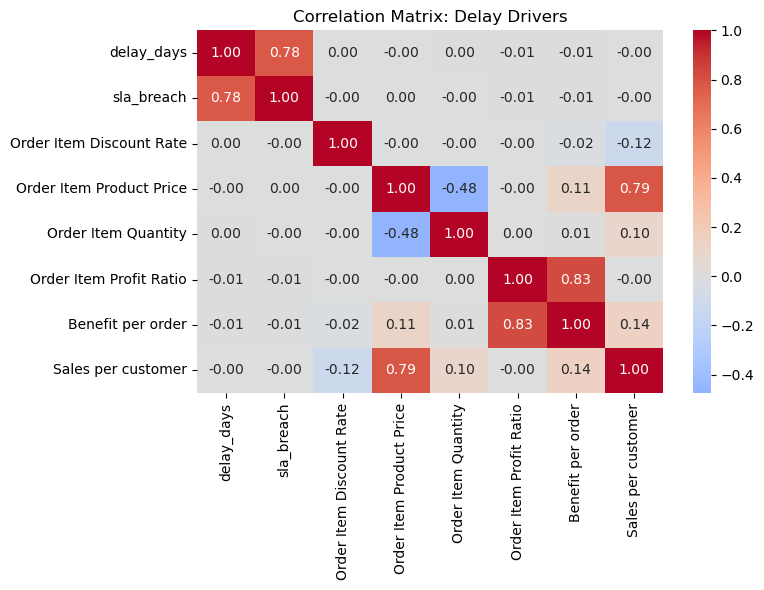

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    "delay_days", "sla_breach", "Order Item Discount Rate", "Order Item Product Price",
    "Order Item Quantity", "Order Item Profit Ratio", "Benefit per order", "Sales per customer",
]
numeric_cols = [c for c in numeric_cols if c in clean.columns]

corr = clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Delay Drivers")
plt.tight_layout()
plt.savefig("data/processed/correlation_heatmap.png", dpi=150)
plt.show()

In [34]:
clean.groupby("carrier")[["Order Item Discount Rate", "Order Item Product Price",
                            "Order Item Quantity", "Order Item Profit Ratio"]].mean().round(3)

,Order Item Discount Rate,Order Item Product Price,Order Item Quantity,Order Item Profit Ratio
carrier,,,,
Carrier A (Ground),0.102,142.874,2.119,0.125
Carrier B (Expedited),0.101,142.938,2.106,0.120
Carrier C (Premium),0.103,136.411,2.151,0.122


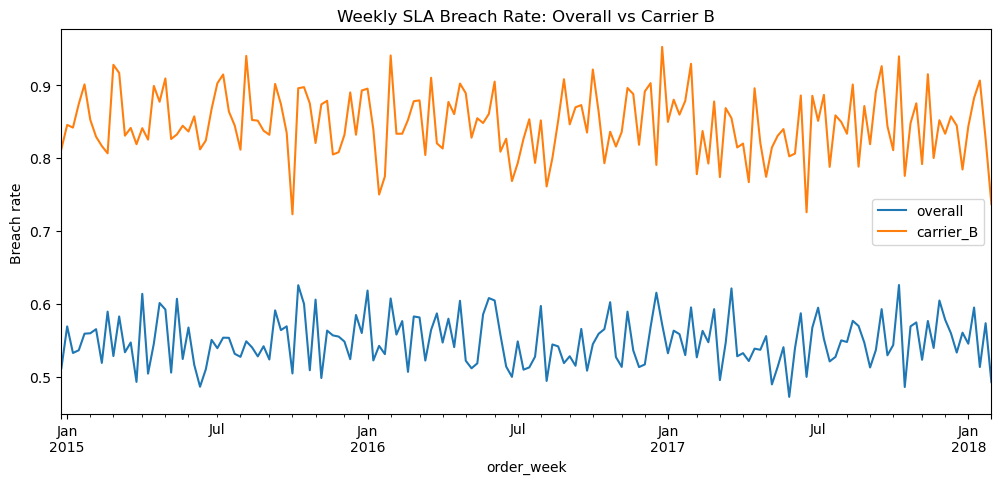

In [35]:
weekly_overall = clean.groupby("order_week")["sla_breach"].mean().rename("overall")
weekly_carrierB = (
    clean[clean["carrier"] == "Carrier B (Expedited)"]
    .groupby("order_week")["sla_breach"].mean().rename("carrier_B")
)

trend = pd.concat([weekly_overall, weekly_carrierB], axis=1)

trend.plot(figsize=(12, 5), title="Weekly SLA Breach Rate: Overall vs Carrier B")
plt.ylabel("Breach rate")
plt.savefig("data/processed/weekly_trend.png", dpi=150)
plt.show()

In [37]:
pip install statsmodels --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [41]:
series = weekly_carrierB.asfreq("W-MON").interpolate(limit_direction="both")

print(series.isna().sum())   # should be 0 now
series.head()

0


order_week
2014-12-29    0.812500
2015-01-05    0.845455
2015-01-12    0.841727
2015-01-19    0.873950
2015-01-26    0.900990
Freq: W-MON, Name: carrier_B, dtype: float64

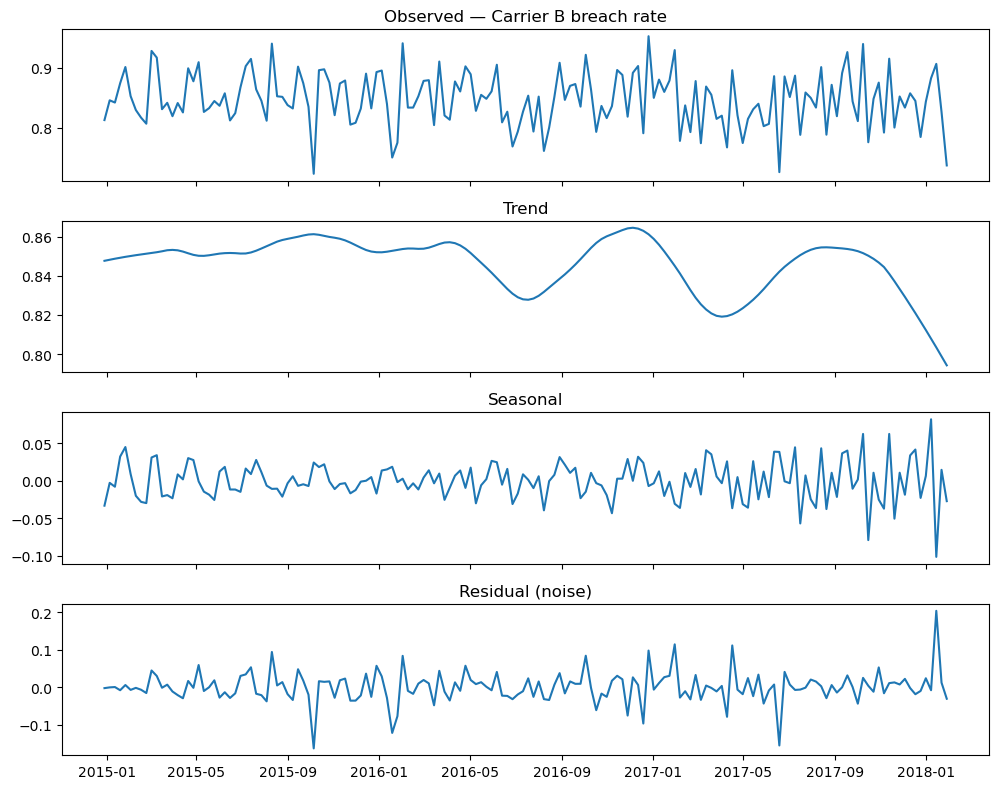

In [42]:
from statsmodels.tsa.seasonal import STL

stl = STL(series, period=13, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
axes[0].plot(series); axes[0].set_title("Observed — Carrier B breach rate")
axes[1].plot(result.trend); axes[1].set_title("Trend")
axes[2].plot(result.seasonal); axes[2].set_title("Seasonal")
axes[3].plot(result.resid); axes[3].set_title("Residual (noise)")
plt.tight_layout()
plt.savefig("data/processed/carrierB_decomposition.png", dpi=150)
plt.show()

DataCoSupplyChainDataset.csv
DescriptionDataCoSupplyChain.csv
Sample - Superstore.csv
tokenized_access_logs.csv
